<a href="https://colab.research.google.com/github/ldamaske/1IAST-Fase1/blob/main/Data_Science_Desafios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd # importacao da biblioteca para tratamento dos dados e criacao de dataframe formato colunar
import matplotlib.pyplot as plt

import numpy as np
import statistics as stats
import seaborn as sns

In [5]:
nps=pd.read_csv("/content/desafio_nps_fase_1.csv")
nps

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7


In [6]:
nps['nps_score'].describe()


,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


In [ ]:
nps['customer_region'].describe()

,customer_region
count,2500
unique,5
top,Sul
freq,521


In [ ]:
nps.groupby('customer_region')['nps_score'].mean().reset_index()

,customer_region,nps_score
0,Centro-Oeste,4.209829
1,Nordeste,4.421649
2,Norte,4.382609
3,Sudeste,4.373846
4,Sul,4.490979


In [8]:
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

nps['nps_categoria'] = nps['nps_score'].apply(classificar_nps)

In [9]:
percentual = nps['nps_categoria'].value_counts(normalize=True) * 100

nps = percentual.get('Promotor', 0) - percentual.get('Detrator', 0)

print(f'NPS: {nps:.2f}')

NPS: -66.00


In [21]:
import pandas as pd
nps = pd.read_csv("/content/desafio_nps_fase_1.csv")
corr = nps['csat_internal_score'].corr(nps['nps_score'])
print(f'Correlação CSAT vs NPS: {corr:.2f}')

Correlação CSAT vs NPS: 0.56


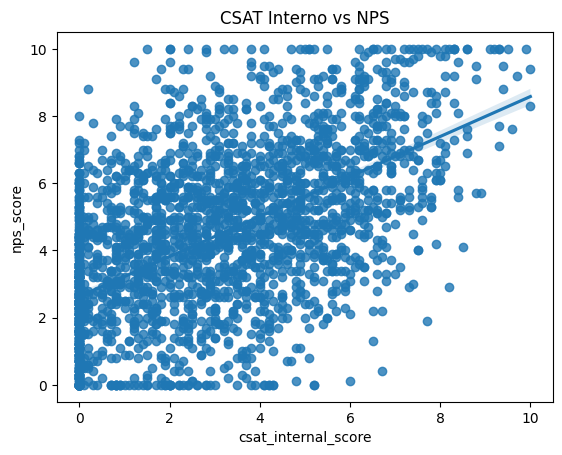

In [15]:
#se existe uma correlação entre o nps que o cliente da nota com a nota interna tavelz do processo

sns.regplot(data=nps, x='csat_internal_score', y='nps_score')
plt.title('CSAT Interno vs NPS')
plt.show()

In [19]:
#
X = nps[['delivery_delay_days', 'customer_age']]
y = nps['nps_score']

In [22]:
#
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd #

# Definindo a funcao de categorizar o score_nps
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

# Aplicando a classificação classificação a nps_score para criar um alvo categórico'
# O 'nps' contido no dataframe é
y_categorical = nps['nps_score'].apply(classificar_nps)

#Agora, use o y categórico para train_test_split
# Assume-se que X esteja definido a partir de uma célula anterior
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42) # Added random_state for reproducibility

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [23]:
accuracy = model.score(X_test, y_test)
print(f'Acurácia do modelo: {accuracy:.2f}')

Acurácia do modelo: 0.72


In [24]:
y_pred = model.predict(X_test)

In [25]:
#
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Detrator       0.74      0.98      0.84       363
      Neutro       0.00      0.00      0.00        98
    Promotor       0.25      0.10      0.15        39

    accuracy                           0.72       500
   macro avg       0.33      0.36      0.33       500
weighted avg       0.55      0.72      0.62       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
#Impacto de cada variável em cada classe
#Ex: tempo alto aumenta chance de ser detrator
model.coef_

array([[ 0.71929059, -0.00258556],
       [-0.0034263 , -0.00168701],
       [-0.71586429,  0.00427257]])

In [27]:
#Probabilidades
model.predict_proba(X_test)


array([[5.97121926e-01, 2.72359047e-01, 1.30519026e-01],
       [7.91227839e-01, 1.72378940e-01, 3.63932210e-02],
       [3.43784727e-01, 3.25064057e-01, 3.31151216e-01],
       ...,
       [9.47935417e-01, 4.93254402e-02, 2.73914282e-03],
       [7.75507945e-01, 1.75925729e-01, 4.85663255e-02],
       [9.73959827e-01, 2.52282901e-02, 8.11883292e-04]])

In [ ]:
#tudo que é construido tem o seu atributo exemplo quais linhas colunas
notas.shape

(100836, 4)

In [ ]:
#alterando nomes das colunas ja que dentro de um conjunto há mais de um elemento ou seja []
notas.columns=["usuarioId", "filmeId", "nota", "momento"]
notas.head()

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
notas["nota"].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [ ]:
#contando valores dentro de um conjunto de dados de uma coluna
notas["nota"].value_counts()

KeyError: 'nota'

In [ ]:
#media desse conjunto de itens desse grupo de valores
notas["nota"].mean()

np.float64(3.501556983616962)

In [ ]:
pd.read_csv('/ratings.csv')

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
#usar metodos exemplo mediana para descobrir o meio de uma amostra
notas['nota'].median()


3.5

In [ ]:
mediana = notas["nota"].median()
media = notas["nota"].mean()
print(f"Mediana é {mediana}")
print(f"Média é {media}")

Mediana é 3.5
Média é 3.501556983616962


In [ ]:
#uma breve descriva do dataframe um descritivo
notas['nota'].describe()

,nota
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


<Axes: ylabel='nota'>

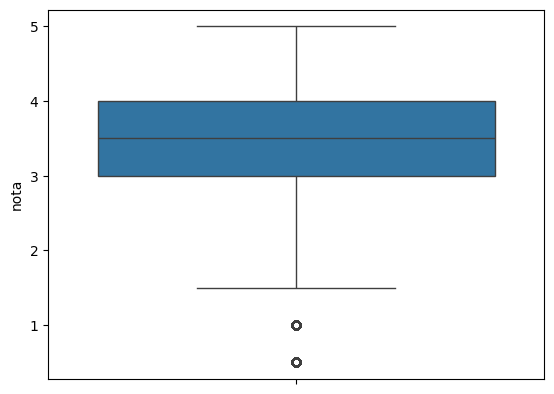

In [ ]:
#quero saber em forma de grafico aonde se concentra o publico no range de notas, usamos o
import seaborn as sns
sns.boxplot(notas["nota"])

In [ ]:
#atividade de entendimento
import pandas as pd

# Criando um DataFrame simples
dados = { 'Nome': ['Mirla', 'Ana', 'Daniel'],
   'Idade': [25, 30, 35],
              'Salario': [5000, 6000, 8000]}
df = pd.DataFrame(dados)
df

In [ ]:
#amostragem aleatória randomica
#amostragem estratifica seleciona alguns grupos respectivamente
#vies a base tem certo vicio
#tervalo de confiança=fixa da dsitribuição de seus dados, estimar certa confiança,media
#alguns requisitios para este intervalo de confiança(primeira a distruiblção dos dados)
#bootstrap reamostragem em cima de uma amostra que nao segue uma anormalidade assimetrica vdrificar outliers
#

In [ ]:
Teste t independente
t = -4.8475
p-value = 0.0000 < 0.05. Há evidência estatística para diferença significativa.
Teste t pareado
t = -20.1083
p-value = 0.0000 < 0.05. Há evidência estatística para diferença significativa.